# 🔁 Cross-Validation — Complete Example

**Purpose:** Learn how to properly evaluate model performance using cross-validation.

**What you'll learn:**
- Why a single train/test split isn't enough
- How to implement K-Fold cross-validation
- How to interpret cross-validation results
- How to detect overfitting and unstable models

---

## 💡 Why Cross-Validation?

**Problem with single split:**
- You might get "lucky" or "unlucky" with your validation set
- Results depend heavily on which data points ended up in train vs validation
- Hard to know if your model will generalize well

**Solution: Cross-Validation**
- Split data into K parts ("folds")
- Train K times, each time using a different fold as validation
- Get K performance scores instead of just 1
- Calculate mean and standard deviation to understand stability

**Example (5-Fold CV):**
```
Fold 1: [Val][Train][Train][Train][Train]
Fold 2: [Train][Val][Train][Train][Train]
Fold 3: [Train][Train][Val][Train][Train]
Fold 4: [Train][Train][Train][Val][Train]
Fold 5: [Train][Train][Train][Train][Val]
```

This way, every data point is used for validation exactly once!

## Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score
)
from catboost import Pool, CatBoostClassifier

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)

print("✓ Libraries imported")

✓ Libraries imported


## Configuration

In [2]:
# Target column
TARGET_COL = "churn"

# Target recall (business requirement)
TARGET_RECALL = 0.80

# ID columns to drop
ID_COLS = ["idconsumo", "codigocontaservico", "idconta", "iddim_cliente", 
           "idcliente", "codigocliente", "iddim_conta", "codigoconta"]

# Number of folds for cross-validation
N_FOLDS = 5  # Common choice: 5-10 folds

print(f"✓ Configuration:")
print(f"  Target: {TARGET_COL}")
print(f"  Target recall: {TARGET_RECALL:.0%}")
print(f"  Number of folds: {N_FOLDS}")

✓ Configuration:
  Target: churn
  Target recall: 80%
  Number of folds: 5


## 1. Load Data

We use the splits from **Module 1's EDA notebook** (`../1. EDA/eda_example_results/`) — they still have the date column, which `TimeSeriesSplit` needs. Module 2's cleaned outputs drop the date columns, so they wouldn't work here.

**Important:** We combine train and validation sets because cross-validation will create its own splits!

In [3]:
# Where to read the splits from.
# We use Module 1's EDA outputs (not Module 2's cleaned output) because we need
# the date column for TimeSeriesSplit — Module 2's data-prep drops datetimes
# before training. CatBoost handles missing values natively, so we don't need
# Module 2's explicit missing-value fills here.
DATA_DIR = "../1. EDA/eda_example_results"

train_df = pd.read_parquet(f"{DATA_DIR}/train.parquet")
val_df   = pd.read_parquet(f"{DATA_DIR}/val.parquet")

# Combine train and validation for cross-validation
# (CV creates its own train/val splits per fold)
df = pd.concat([train_df, val_df], axis=0, ignore_index=True)

print(f"✓ Loaded data:")
print(f"  Train: {len(train_df):,} rows")
print(f"  Val:   {len(val_df):,} rows")
print(f"  Total: {len(df):,} rows")
print(f"  Churn rate: {df[TARGET_COL].mean():.1%}")

✓ Loaded data:
  Train: 82,717 rows
  Val:   10,340 rows
  Total: 93,057 rows
  Churn rate: 36.9%


## 2. Prepare Features

Same preprocessing as in previous notebooks.

In [4]:
# Drop ID columns (we don't need these for modeling)
id_cols = [col for col in ID_COLS if col in df.columns]
df = df.drop(columns=id_cols)

# Separate features (X) and target (y)
y = df[TARGET_COL].values            # What we want to predict
X = df.drop(columns=[TARGET_COL])    # Everything else

# IMPORTANT: Sort by date FIRST for time-series cross-validation
# This ensures we train on past data and validate on future data (no cheating!)
date_col = 'iddim_date_inicio'
X[date_col] = pd.to_datetime(X[date_col])
sort_order = X[date_col].argsort().values
X = X.iloc[sort_order].reset_index(drop=True)
y = y[sort_order]

# Keep a sorted-dates Series so the fold visualization below indexes the SAME
# row order as X. (Earlier versions indexed into the unsorted `df` — the bar
# chart's date labels were misleading.)
dates_sorted = X[date_col].copy()

print(f"✓ Sorted by date for temporal cross-validation")
print(f"  Date range: {dates_sorted.min().date()} to {dates_sorted.max().date()}")

# Drop ALL datetime columns (CatBoost can't consume them as features).
# Using dtype here instead of a hardcoded list catches every datetime column,
# including ones we forgot about — like `last_contact_ts` in this dataset.
datetime_cols = X.select_dtypes(include='datetime64').columns.tolist()
X = X.drop(columns=datetime_cols)
print(f"  Dropped {len(datetime_cols)} datetime feature column(s): {datetime_cols}")

# Drop any rows where the target itself is missing
target_mask = ~pd.isna(y)
if (~target_mask).any():
    n_dropped = (~target_mask).sum()
    X = X.loc[target_mask].reset_index(drop=True)
    y = y[target_mask]
    dates_sorted = dates_sorted.loc[target_mask].reset_index(drop=True)
    print(f"  Dropped {n_dropped:,} rows with missing target")
y = y.astype(int)

# Fill missing values — CatBoost handles NaN, but pandas may have Python `None`
# in object columns from parquet, which CatBoost rejects. Same strategy as
# Module 2's clean_data: 0 for numerics, '<MISSING>' sentinel for categoricals.
for col in X.select_dtypes(include='number').columns:
    if X[col].isnull().any():
        X[col] = X[col].fillna(0)
for col in X.select_dtypes(include='object').columns:
    if X[col].isnull().any():
        X[col] = X[col].fillna('<MISSING>')

# Find which columns are categorical (text) vs numeric (numbers)
cat_features = X.select_dtypes(include=['object']).columns.tolist()
cat_indices  = [X.columns.get_loc(col) for col in cat_features]

print(f"\n✓ Prepared features:")
print(f"  {len(X.columns)} total features")
print(f"  {len(cat_features)} categorical features")
print(f"  {len(y):,} total samples")
print(f"  {X.isnull().sum().sum():,} remaining missing values (should be 0)")

✓ Sorted by date for temporal cross-validation
  Date range: 2021-02-08 to 2025-04-19
  Dropped 3 datetime feature column(s): ['iddim_date_inicio', 'iddim_date_fim', 'last_contact_ts']

✓ Prepared features:
  46 total features
  9 categorical features
  93,057 total samples
  0 remaining missing values (should be 0)


## 3. Implement Cross-Validation

We'll use **TimeSeriesSplit** which respects temporal order - each fold trains on past data and validates on future data. This prevents data leakage!

Starting 5-fold cross-validation...
Training on PAST → Validating on FUTURE (prevents data leakage!)

Fold 1/5...
  Train: 15,512 | Val: 15,509
  ROC-AUC: 0.7368 | Precision: 0.5478 | Recall: 0.8000

Fold 2/5...
  Train: 31,021 | Val: 15,509
  ROC-AUC: 0.7640 | Precision: 0.5315 | Recall: 0.8001

Fold 3/5...
  Train: 46,530 | Val: 15,509
  ROC-AUC: 0.7686 | Precision: 0.5148 | Recall: 0.8001

Fold 4/5...
  Train: 62,039 | Val: 15,509
  ROC-AUC: 0.7599 | Precision: 0.5122 | Recall: 0.8001

Fold 5/5...
  Train: 77,548 | Val: 15,509
  ROC-AUC: 0.7695 | Precision: 0.4766 | Recall: 0.8000

✓ Cross-validation complete!

📅 Visualizing temporal splits...



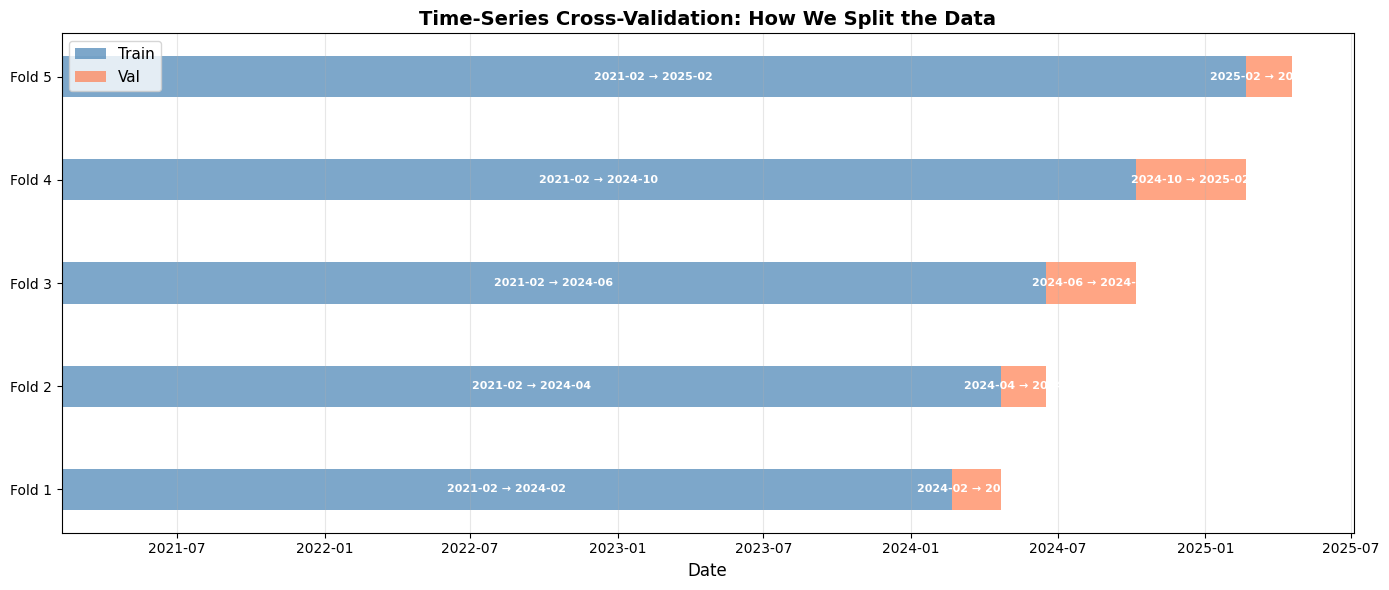


💡 Key points:
  • Blue = Training data (past)
  • Orange = Validation data (future)
  • Each fold uses MORE past data than before
  • Validation ALWAYS comes after training (no peeking into the future!)


In [5]:
# Create TimeSeriesSplit - this splits data chronologically
# Each fold trains on past data and validates on future data
tscv = TimeSeriesSplit(n_splits=N_FOLDS)

# Lists to store results
fold_results = []
fold_dates = []

print(f"Starting {N_FOLDS}-fold cross-validation...")
print(f"Training on PAST → Validating on FUTURE (prevents data leakage!)\n")

# Loop through each fold
for fold_num, (train_idx, val_idx) in enumerate(tscv.split(X), start=1):
    
    print(f"Fold {fold_num}/{N_FOLDS}...")
    
    # Split data for this fold
    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]
    y_train = y[train_idx]
    y_val = y[val_idx]
    
    # Save date ranges for the fold visualization below.
    # Use the SORTED dates Series — indexing into the unsorted `df` would mis-label folds.
    train_dates = dates_sorted.iloc[train_idx]
    val_dates   = dates_sorted.iloc[val_idx]
    fold_dates.append({
        'fold': fold_num,
        'train_start': train_dates.min(),
        'train_end': train_dates.max(),
        'val_start': val_dates.min(),
        'val_end': val_dates.max()
    })
    
    # Create CatBoost data structures
    train_pool = Pool(X_train, y_train, cat_features=cat_indices)
    val_pool = Pool(X_val, y_val, cat_features=cat_indices)
    
    # Train model with TUNED hyperparameters (from hyperparameter tuning notebook)
    model = CatBoostClassifier(
        iterations=811,
        learning_rate=0.044,
        depth=5,
        l2_leaf_reg=1.015,
        random_seed=SEED,
        verbose=False,
        eval_metric='PRAUC'
    )
    
    model.fit(train_pool, eval_set=val_pool, use_best_model=True, early_stopping_rounds=50)
    
    # Get predictions (probabilities, not 0/1)
    y_val_proba = model.predict_proba(val_pool)[:, 1]
    
    # Calculate performance metrics
    roc_auc = roc_auc_score(y_val, y_val_proba)
    pr_auc = average_precision_score(y_val, y_val_proba)
    
    # Find best threshold to achieve target recall (80%)
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba)
    idx = np.where(recalls[:-1] >= TARGET_RECALL)[0]
    
    if len(idx) > 0:
        idx = idx[-1]  # Get last threshold that achieves target recall
        threshold = thresholds[idx]
        precision = precisions[idx]
        recall = recalls[idx]
    else:
        # Can't reach target recall, use default
        threshold = 0.5
        y_val_pred = (y_val_proba >= threshold).astype(int)
        precision = precision_score(y_val, y_val_pred)
        recall = recall_score(y_val, y_val_pred)
    
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    # Save results
    fold_results.append({
        'fold': fold_num,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'train_size': len(train_idx),
        'val_size': len(val_idx)
    })
    
    print(f"  Train: {len(train_idx):,} | Val: {len(val_idx):,}")
    print(f"  ROC-AUC: {roc_auc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}\n")

print("✓ Cross-validation complete!\n")

# === Visualize how we split the data by time ===
print("📅 Visualizing temporal splits...\n")

fig, ax = plt.subplots(figsize=(14, 6))

for fold_info in fold_dates:
    fold_num = fold_info['fold']
    
    # Training period (blue)
    train_days = (fold_info['train_end'] - fold_info['train_start']).days
    ax.barh(fold_num, train_days, left=fold_info['train_start'], 
            height=0.4, color='steelblue', alpha=0.7,
            label='Train' if fold_num == 1 else '')
    
    # Validation period (orange)
    val_days = (fold_info['val_end'] - fold_info['val_start']).days
    ax.barh(fold_num, val_days, left=fold_info['val_start'],
            height=0.4, color='coral', alpha=0.7,
            label='Val' if fold_num == 1 else '')
    
    # Add date labels
    train_mid = fold_info['train_start'] + (fold_info['train_end'] - fold_info['train_start']) / 2
    val_mid = fold_info['val_start'] + (fold_info['val_end'] - fold_info['val_start']) / 2
    ax.text(train_mid, fold_num, 
            f"{fold_info['train_start'].strftime('%Y-%m')} → {fold_info['train_end'].strftime('%Y-%m')}", 
            ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    ax.text(val_mid, fold_num,
            f"{fold_info['val_start'].strftime('%Y-%m')} → {fold_info['val_end'].strftime('%Y-%m')}", 
            ha='center', va='center', fontsize=8, color='white', fontweight='bold')

ax.set_yticks(range(1, N_FOLDS + 1))
ax.set_yticklabels([f'Fold {i}' for i in range(1, N_FOLDS + 1)])
ax.set_xlabel('Date', fontsize=12)
ax.set_title('Time-Series Cross-Validation: How We Split the Data', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n💡 Key points:")
print("  • Blue = Training data (past)")
print("  • Orange = Validation data (future)")
print("  • Each fold uses MORE past data than before")
print("  • Validation ALWAYS comes after training (no peeking into the future!)")

## 4. Analyze Results

Let's look at the results across all folds and calculate summary statistics.

In [6]:
# Convert to DataFrame for easier analysis
results_df = pd.DataFrame(fold_results)

print("📊 Cross-Validation Results:\n")
print(results_df.to_string(index=False))

# Calculate mean and standard deviation for each metric
print("\n📈 Summary Statistics:\n")

metrics = ['roc_auc', 'pr_auc', 'precision', 'recall', 'f1']
for metric in metrics:
    mean_val = results_df[metric].mean()
    std_val = results_df[metric].std()
    min_val = results_df[metric].min()
    max_val = results_df[metric].max()
    print(f"  {metric.upper():12s}: {mean_val:.4f} ± {std_val:.4f}  (range: {min_val:.4f} - {max_val:.4f})")

📊 Cross-Validation Results:

 fold  roc_auc   pr_auc  threshold  precision   recall       f1  train_size  val_size
    1 0.736828 0.647153   0.402707   0.547807 0.800031 0.650319       15512     15509
    2 0.764031 0.631543   0.335413   0.531485 0.800139 0.638711       31021     15509
    3 0.768590 0.618649   0.317827   0.514757 0.800149 0.626481       46530     15509
    4 0.759907 0.613467   0.305232   0.512218 0.800073 0.624574       62039     15509
    5 0.769547 0.591900   0.261133   0.476598 0.800000 0.597335       77548     15509

📈 Summary Statistics:

  ROC_AUC     : 0.7598 ± 0.0134  (range: 0.7368 - 0.7695)
  PR_AUC      : 0.6205 ± 0.0206  (range: 0.5919 - 0.6472)
  PRECISION   : 0.5166 ± 0.0265  (range: 0.4766 - 0.5478)
  RECALL      : 0.8001 ± 0.0001  (range: 0.8000 - 0.8001)
  F1          : 0.6275 ± 0.0198  (range: 0.5973 - 0.6503)


## 5. Visualize Results

Visualizations help us understand model stability across folds.

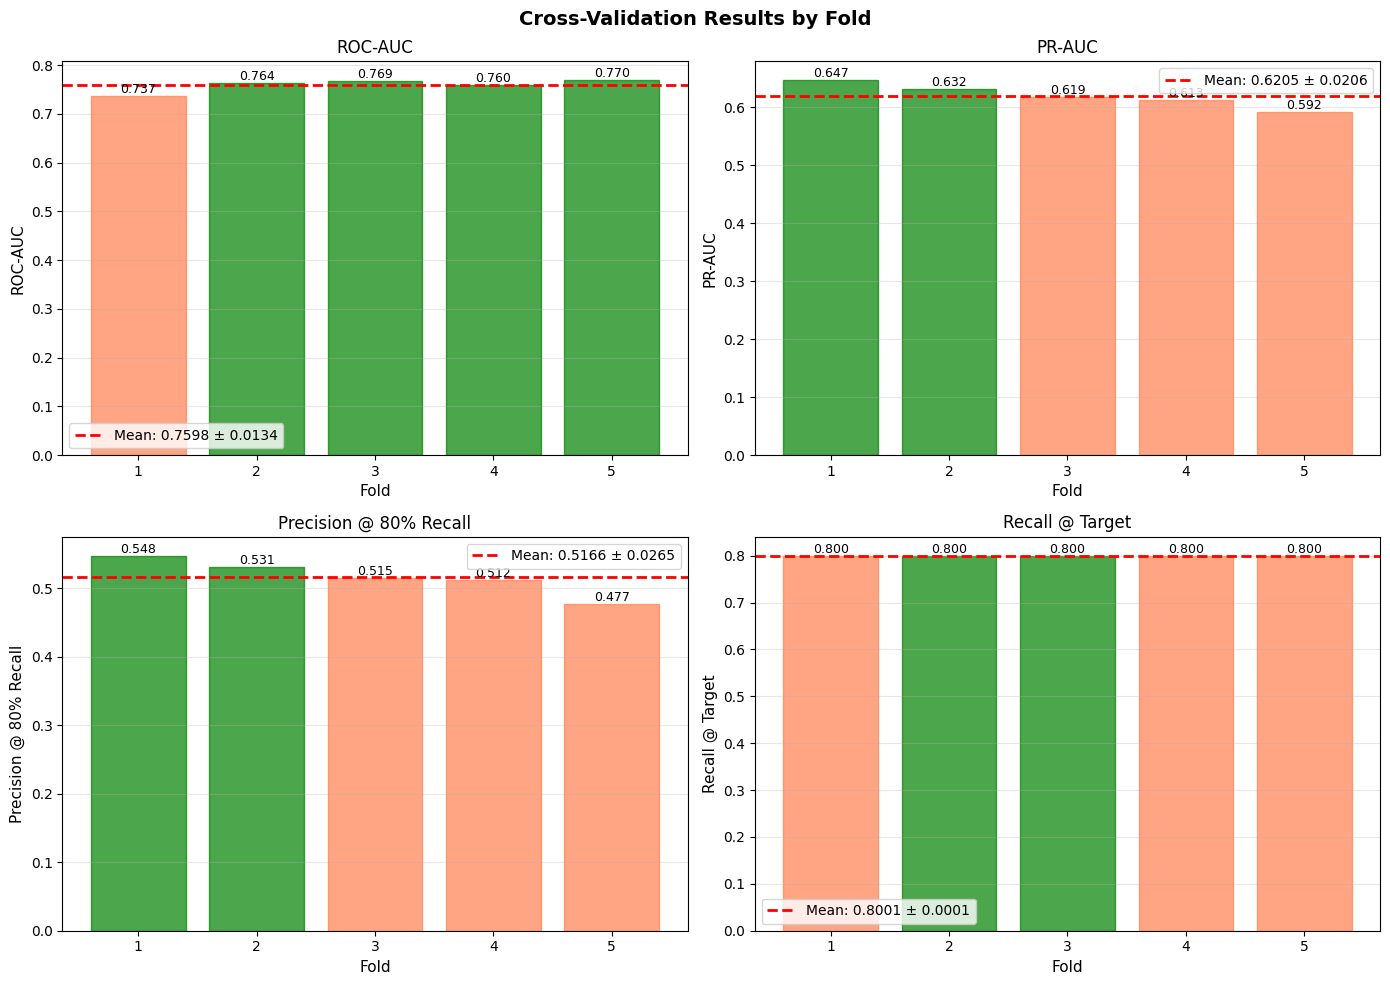


💡 What to look for:
  - Bars should be roughly the same height (stable model)
  - Green bars = above average, Red bars = below average
  - Small std (±) = more reliable model


In [7]:
# Create bar plots showing each fold's performance
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Cross-Validation Results by Fold', fontsize=14, fontweight='bold')

metrics = ['roc_auc', 'pr_auc', 'precision', 'recall']
titles = ['ROC-AUC', 'PR-AUC', 'Precision @ 80% Recall', 'Recall @ Target']

for ax, metric, title in zip(axes.flat, metrics, titles):
    # Create bar plot
    bars = ax.bar(results_df['fold'], results_df[metric], alpha=0.7)
    
    # Color bars: green if above mean, red if below
    mean_val = results_df[metric].mean()
    colors = ['green' if val >= mean_val else 'coral' for val in results_df[metric]]
    for bar, color in zip(bars, colors):
        bar.set_color(color)
    
    # Add mean line
    std_val = results_df[metric].std()
    ax.axhline(mean_val, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_val:.4f} ± {std_val:.4f}')
    
    # Add value labels on bars
    for i, val in enumerate(results_df[metric]):
        ax.text(i+1, val, f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    
    ax.set_xlabel('Fold', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

print("\n💡 What to look for:")
print("  - Bars should be roughly the same height (stable model)")
print("  - Green bars = above average, Red bars = below average")
print("  - Small std (±) = more reliable model")

## 6. Stability Analysis

Let's check if the model is stable across folds.

In [8]:
# Calculate coefficient of variation (CV) for each metric
# CV = std / mean (lower is better, typically want < 0.05)
print("📊 Model Stability Analysis:\n")

for metric in ['roc_auc', 'pr_auc', 'precision', 'recall', 'f1']:
    mean_val = results_df[metric].mean()
    std_val = results_df[metric].std()
    cv = std_val / mean_val if mean_val > 0 else 0
    
    stability = "✓ Stable" if cv < 0.05 else "⚠️ Unstable"
    print(f"  {metric.upper():12s}: CV = {cv:.4f}  {stability}")

print("\n💡 Interpretation:")
print("  - CV < 0.05: Model is stable (good!)")
print("  - CV > 0.05: Model is unstable (investigate further)")

# Identify worst and best folds
worst_fold = results_df.loc[results_df['roc_auc'].idxmin()]
best_fold = results_df.loc[results_df['roc_auc'].idxmax()]

print(f"\n📉 Worst fold: Fold {worst_fold['fold']} (ROC-AUC: {worst_fold['roc_auc']:.4f})")
print(f"📈 Best fold:  Fold {best_fold['fold']} (ROC-AUC: {best_fold['roc_auc']:.4f})")
print(f"📊 Range:      {best_fold['roc_auc'] - worst_fold['roc_auc']:.4f}")

📊 Model Stability Analysis:

  ROC_AUC     : CV = 0.0176  ✓ Stable
  PR_AUC      : CV = 0.0333  ✓ Stable
  PRECISION   : CV = 0.0514  ⚠️ Unstable
  RECALL      : CV = 0.0001  ✓ Stable
  F1          : CV = 0.0315  ✓ Stable

💡 Interpretation:
  - CV < 0.05: Model is stable (good!)
  - CV > 0.05: Model is unstable (investigate further)

📉 Worst fold: Fold 1.0 (ROC-AUC: 0.7368)
📈 Best fold:  Fold 5.0 (ROC-AUC: 0.7695)
📊 Range:      0.0327


## 7. Compare Single Split vs Cross-Validation

Let's demonstrate why a single split can be misleading.

In [9]:
from sklearn.model_selection import train_test_split

# Simulate what we would get with a single random split
print("🎲 Simulating 10 different random train/test splits...\n")

single_split_results = []

for i in range(10):
    # Create a random split
    X_tr, X_va, y_tr, y_va = train_test_split(
        X, y, test_size=0.2, random_state=i, stratify=y
    )
    
    # Train and evaluate with TUNED hyperparameters
    train_pool = Pool(X_tr, y_tr, cat_features=cat_indices)
    val_pool = Pool(X_va, y_va, cat_features=cat_indices)
    
    model = CatBoostClassifier(
        iterations=811, learning_rate=0.044, depth=5, l2_leaf_reg=1.015,
        random_seed=SEED, verbose=False, eval_metric='PRAUC'
    )
    model.fit(train_pool, eval_set=val_pool, use_best_model=True, early_stopping_rounds=50)
    
    y_va_proba = model.predict_proba(val_pool)[:, 1]
    roc_auc = roc_auc_score(y_va, y_va_proba)
    single_split_results.append(roc_auc)
    print(f"  Split {i+1}: ROC-AUC = {roc_auc:.4f}")

# Compare single split vs CV
cv_mean = results_df['roc_auc'].mean()
cv_std = results_df['roc_auc'].std()
ss_mean = np.mean(single_split_results)
ss_std = np.std(single_split_results)

print(f"\n📊 Comparison:")
print(f"  Single splits:      {ss_mean:.4f} ± {ss_std:.4f}  (range: {min(single_split_results):.4f} - {max(single_split_results):.4f})")
print(f"  Cross-validation:   {cv_mean:.4f} ± {cv_std:.4f}  (range: {results_df['roc_auc'].min():.4f} - {results_df['roc_auc'].max():.4f})")

print(f"\n💡 Insight:")
print(f"  If you had used just ONE random split, you might get anywhere from {min(single_split_results):.4f} to {max(single_split_results):.4f}!")
print(f"  Cross-validation gives you a more reliable estimate with less variance.")

🎲 Simulating 10 different random train/test splits...

  Split 1: ROC-AUC = 0.7695
  Split 2: ROC-AUC = 0.7702
  Split 3: ROC-AUC = 0.7671
  Split 4: ROC-AUC = 0.7678
  Split 5: ROC-AUC = 0.7664
  Split 6: ROC-AUC = 0.7678
  Split 7: ROC-AUC = 0.7687
  Split 8: ROC-AUC = 0.7713
  Split 9: ROC-AUC = 0.7692
  Split 10: ROC-AUC = 0.7721

📊 Comparison:
  Single splits:      0.7690 ± 0.0017  (range: 0.7664 - 0.7721)
  Cross-validation:   0.7598 ± 0.0134  (range: 0.7368 - 0.7695)

💡 Insight:
  If you had used just ONE random split, you might get anywhere from 0.7664 to 0.7721!
  Cross-validation gives you a more reliable estimate with less variance.


## 8. Final Recommendations

Based on the cross-validation results, here's what we learned:

In [10]:
cv_mean_auc = results_df['roc_auc'].mean()
cv_std_auc = results_df['roc_auc'].std()
cv_mean_recall = results_df['recall'].mean()
cv_mean_precision = results_df['precision'].mean()

print("="*70)
print("📋 CROSS-VALIDATION SUMMARY")
print("="*70)

print(f"\n✓ Model Performance:")
print(f"  ROC-AUC:   {cv_mean_auc:.4f} ± {cv_std_auc:.4f}")
print(f"  Precision: {cv_mean_precision:.4f} (at {TARGET_RECALL:.0%} recall)")
print(f"  Recall:    {cv_mean_recall:.4f}")

print(f"\n✓ Model Stability:")
if cv_std_auc < 0.01:
    print(f"  Very stable (std = {cv_std_auc:.4f})")
elif cv_std_auc < 0.03:
    print(f"  Stable (std = {cv_std_auc:.4f})")
else:
    print(f"  ⚠️ Unstable (std = {cv_std_auc:.4f}) - investigate further")

print(f"\n✓ Recommendations:")
if cv_mean_recall >= TARGET_RECALL and cv_std_auc < 0.03:
    print(f"  ✓ Model meets target recall and is stable")
    print(f"  ✓ Safe to train final model on all data")
    print(f"  ✓ Proceed to test set evaluation")
else:
    print(f"  ⚠️ Model needs improvement:")
    if cv_mean_recall < TARGET_RECALL:
        print(f"    - Recall ({cv_mean_recall:.4f}) below target ({TARGET_RECALL:.4f})")
    if cv_std_auc >= 0.03:
        print(f"    - Model is unstable (high variance across folds)")
    print(f"  💡 Consider:")
    print(f"    - More data")
    print(f"    - Better features")
    print(f"    - Different hyperparameters")
    print(f"    - Different algorithm")

print("\n" + "="*70)

📋 CROSS-VALIDATION SUMMARY

✓ Model Performance:
  ROC-AUC:   0.7598 ± 0.0134
  Precision: 0.5166 (at 80% recall)
  Recall:    0.8001

✓ Model Stability:
  Stable (std = 0.0134)

✓ Recommendations:
  ✓ Model meets target recall and is stable
  ✓ Safe to train final model on all data
  ✓ Proceed to test set evaluation



---
## 🎓 Key Takeaways

1. **Single splits are risky** - Performance varies based on random split
2. **Cross-validation gives confidence** - Multiple evaluations show if model is stable
3. **TimeSeriesSplit prevents data leakage** - Always train on past, validate on future
4. **Report mean ± std** - This is how you communicate model performance properly
5. **More folds = more reliable** - But also slower (5-10 is typical)

## 💡 Best Practices

- **Always use cross-validation** for model selection and evaluation
- **Use TimeSeriesSplit for temporal data** - Prevents data leakage (like our churn data!)
- **Use StratifiedKFold for non-temporal** - Maintains class balance for random data
- **Report both mean and std** - "ROC-AUC: 0.77 ± 0.02"
- **Check coefficient of variation** - CV = std/mean < 0.05 is good
- **Sort by date FIRST** - Critical step before TimeSeriesSplit

## 🚀 Next Steps

After cross-validation:
1. **If model is stable** - Train final model on ALL data (train + val)
2. **If model is unstable** - Investigate why (bad features? Not enough data?)
3. **Evaluate on test set** - Final unbiased evaluation before deployment
4. **Never use test set for tuning** - Test set is only for final evaluation!